# TrustEdge — Churn Model Training & Evaluation
### Hackathon ML Stand-in for Temporal Graph Neural Network (TGN)
This notebook trains a Random Forest Classifier on synthetic customer signals to predict churn probability, maps the risk factors, and extracts the Churn DNA breakdown.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../ml'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score

from generate_dataset import generate_customer_dataset
from churn_model import FEATURE_COLS

## 1. Dataset Generation
We generate synthetic customer signals mapping directly to `CustomerSignal` model signals in the DB.

In [2]:
df = generate_customer_dataset(1500)
print(f"Dataset Shape: {df.shape}")
print(f"Class Distribution:\n{df['churned'].value_counts(normalize=True)}")
df.head()

Dataset Shape: (1500, 15)
Class Distribution:
churned
0    0.864
1    0.136
Name: proportion, dtype: float64


                            customer_id             name  salary_drop_pct  \
0  1a3f793b-aff5-4556-b4fe-78bd2c9eb22f  Vardaniya Kunda             8.84   
1  323d9853-c9e9-469d-a5b6-332ac995da57  Miraan Seshadri            41.34   
2  410b6610-1746-4715-b22a-870da5e2231f        Azad Lala            36.71   
3  5cd0664a-6e2a-4b5a-8d3d-fde144a30736        Eva Agate            44.84   
4  e158afd2-442a-4215-abe0-db824e54651d       Anika Shan            18.69   

   avg_monthly_balance  num_sip_cancellations  app_login_frequency_30d  \
0             32067.00                      0                        7   
1             96370.46                      0                        9   
2             37499.27                      1                        6   
3              3373.71                      1                        8   
4             44711.36                      0                        6   

   digital_txn_ratio  num_complaints_90d  complaint_escalation_flag  \
0             0.6822 

## 2. Model Training

In [3]:
X = df[FEATURE_COLS]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=5, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=5,
                       n_estimators=150, random_state=42)

## 3. Evaluation

In [4]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['STABLE', 'AT_RISK']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      STABLE       0.94      0.93      0.94       259
     AT_RISK       0.59      0.63      0.61        41

    accuracy                           0.89       300
   macro avg       0.77      0.78      0.77       300
weighted avg       0.89      0.89      0.89       300

ROC-AUC Score: 0.9094


## 4. Visualizations

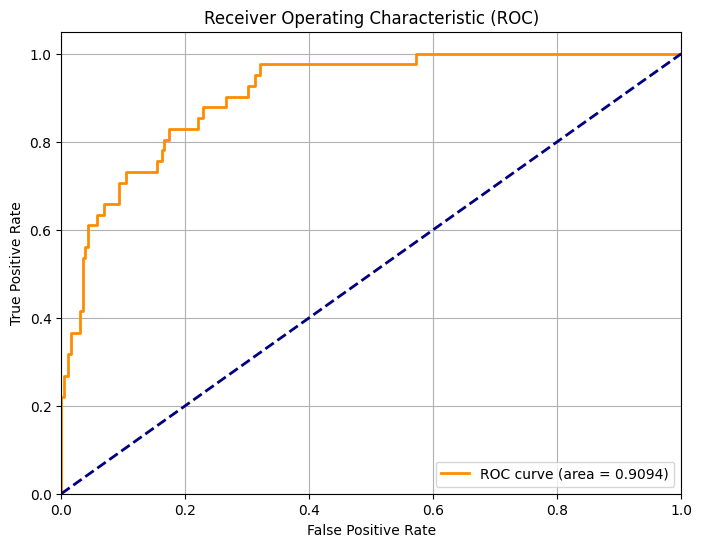

In [5]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

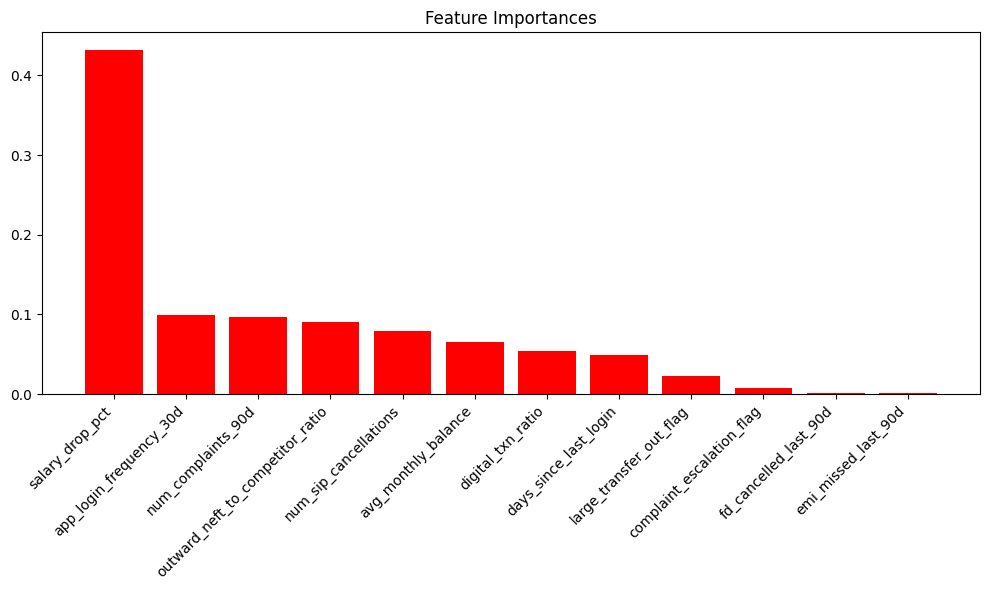

In [6]:
# Feature Importance
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], color="r", align="center")
plt.xticks(range(X.shape[1]), [FEATURE_COLS[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()